In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student-mat.csv", sep=';')

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df['performance'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

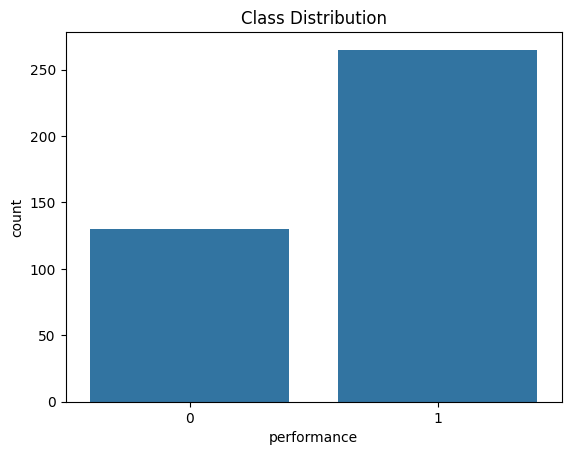

In [5]:
#Basic EDA
sns.countplot(x='performance', data=df)
plt.title('Class Distribution')
plt.show()

In [6]:
#Feature Processing
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(['G1', 'G2', 'G3', 'performance'], axis=1)
y = df['performance']

In [7]:
#Encoding Categorical Features
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols)
])


In [8]:
#Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [9]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

#STRATIFIED K-FOLD CV
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1')
    print(f"{name} F1-score: {scores.mean():.3f}")

LogReg F1-score: 0.787
RF F1-score: 0.793
XGB F1-score: 0.766


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier())
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None]
}

grid = GridSearchCV(pipe, param_grid, cv=skf, scoring='f1')
grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best F1:", grid.best_score_)

Best Params: {'model__max_depth': 10, 'model__n_estimators': 100}
Best F1: 0.8153006434981587


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7468354430379747
F1: 0.8387096774193549
ROC-AUC: 0.6690856313497823


C:\Users\OYEDIRAN ABDULMALIK\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


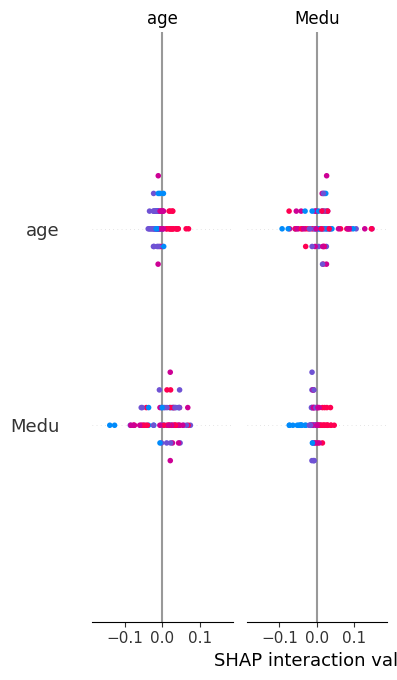

In [12]:
import shap

explainer = shap.Explainer(best_model.named_steps['model'])
shap_values = explainer(best_model.named_steps['prep'].transform(X_test))

shap.summary_plot(shap_values, features=X_test)

In [13]:
import pickle

#saving the trained model into a file
pickle.dump(model, open("model.pkl", "wb"))

In [14]:
from flask import Flask, request, render_template
import joblib
import os


In [15]:
joblib.dump(best_model, 'student_model.pkl')

['student_model.pkl']

In [ ]:
path = r"C:\Users\OYEDIRAN ABDULMALIK\Desktop\MY_PROJECTS\AI_Machine Learning\Student Performance Prediction model"
print("Files currently inside this folder:")
print("---------------------------------")
for file in os.listdir(path):
    print(f"- {file}")
app = Flask(__name__)


model = joblib.load('student_model.pkl')

@app.route("/", methods=["GET", "POST"])
def home():
    prediction = ""

    if request.method == "POST":
        try:
            age = float(request.form['age'])
            studytime = float(request.form['studytime'])
            failures = float(request.form['failures'])
            absences = float(request.form['absences'])

            data = pd.DataFrame([[age, studytime, failure, absences]],
                                columns  = ['age', 'studytime', 'failure', 'absences'])

            pred = model.predict(data)[0]

            prediction = "Pass ✅" if pred == 1 else "Fail ❌" 
        except Exception as e:
            prediction = f"Error: {str(e)}"
        
       
    return render_template("index.html", prediction=prediction)
    print(request.form)

if __name__ == "__main__":
    # Turn off use_reloader to prevent the Jupyter kernel conflict
    app.run(debug=True, use_reloader=False)

Files currently inside this folder:
---------------------------------
- .ipynb_checkpoints
- app.py
- index.html
- model.pkl
- student+performance
- student-mat.csv
- student-mat.ipynb
- Student-performance.ipynb
- student-performance.xlsx
- student-por.csv
- StudentsPerformance.csv
- student_model.pkl
 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
